Processing leader log: ../work/experiments/shabdiz/shabdiz_tplat_48/tsm-sc-000/node1/stellar-core.log
  nodes=48, stable_tput=2160.00 txns/s, stable_avg_latency=87.05 ms, stable_median_latency=28.00 ms
Processing leader log: ../work/experiments/shabdiz/shabdiz_tplat_32/tsm-sc-000/node1/stellar-core.log
  nodes=32, stable_tput=3773.33 txns/s, stable_avg_latency=28.48 ms, stable_median_latency=20.00 ms
Processing leader log: ../work/experiments/shabdiz/shabdiz_tplat_16/tsm-sc-000/node1/stellar-core.log
  nodes=16, stable_tput=10650.00 txns/s, stable_avg_latency=8.54 ms, stable_median_latency=8.00 ms
Processing leader log: ../work/experiments/shabdiz/shabdiz_tplat_8/tsm-sc-000/node1/stellar-core.log
Processing leader log: ../work/experiments/shabdiz/shabdiz_tplat_4/tsm-sc-000/node1/stellar-core.log
  nodes=4, stable_tput=30890.00 txns/s, stable_avg_latency=2.58 ms, stable_median_latency=2.00 ms

Summary:
   num_nodes  stable_avg_throughput_tps  stable_avg_latency_ms  \
0         48       

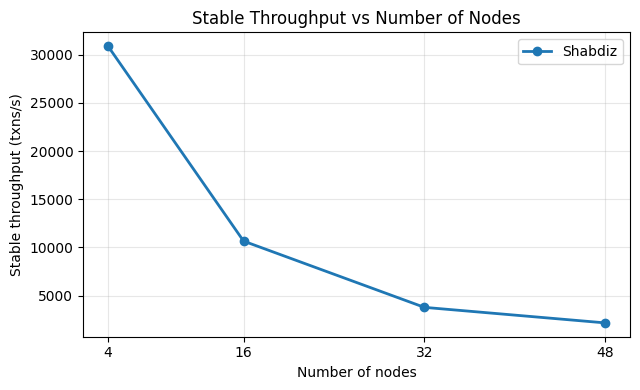

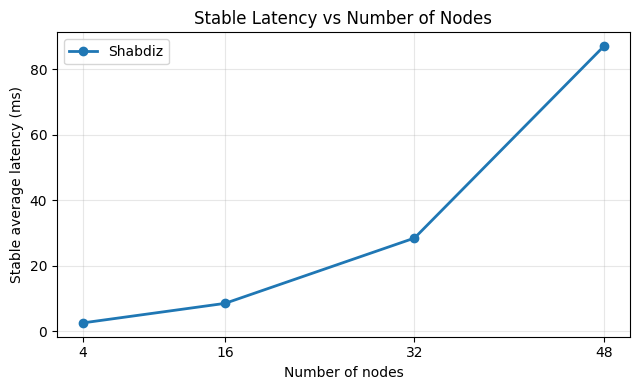

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np
from pathlib import Path

# Leader logs, one per node-count experiment.
log_file_list = [
    "../work/experiments/shabdiz/shabdiz_tplat_48/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shabdiz_tplat_32/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shabdiz_tplat_16/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shabdiz_tplat_8/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shabdiz_tplat_4/tsm-sc-000/node1/stellar-core.log",
]

# Stable window from the end of the experiment.
AVG_WINDOW_START_FROM_END = 60
AVG_WINDOW_END_FROM_END = 30

TS = r"(?P<ts>\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3})"

# ============================================================
# Leader-side proposal patterns only.
# Latency start = leader proposal-send time.
# ============================================================
propose_patterns = [
    ("fast-send", re.compile(
        TS + r".*\[FAST SEND PROPOSE\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+).*txns=(?P<txns>\d+)"
    )),

    ("slow-send", re.compile(
        TS + r".*\[SLOW SEND PROPOSE\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+).*txns=(?P<txns>\d+)"
    )),

    ("send-very-old", re.compile(
        TS + r".*prop\(\): .*proposing block (?P<block>\w+) in view (?P<view>\d+)"
    )),
]

# ============================================================
# Leader-side commit patterns only.
# Throughput and latency end = leader commit time.
# ============================================================
commit_patterns = [
    ("shabdiz", re.compile(
        TS + r".*\[FAST COMMITTED\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+) txns=(?P<txns>\d+)"
    )),

    ("shabdiz-renamed", re.compile(
        TS + r".*\[SHABDIZ COMMITTED\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+) txns=(?P<txns>\d+)"
    )),

    ("iths", re.compile(
        TS + r".*\[IT-HS\] Committed block (?P<block>[0-9a-fA-F]+) view (?P<view>\d+) with (?P<txns>\d+) transactions"
    )),

    ("old", re.compile(
        TS + r".*Committed block (?P<block>\w+) at view (?P<view>\d+) with (?P<txns>\d+) transactions"
    )),
]

# Used only to label slow-path views.
collect_patterns = [
    re.compile(TS + r".*Received COLLECT for view (?P<view>\d+)"),
    re.compile(TS + r".*Leader initiating COLLECT for view (?P<view>\d+)"),
]

def parse_ts(ts_str):
    return datetime.strptime(ts_str, "%Y-%m-%dT%H:%M:%S.%f")

def match_tagged(patterns, line):
    for tag, pat in patterns:
        m = pat.search(line)
        if m:
            return tag, m
    return None, None

def match_any(patterns, line):
    for pat in patterns:
        m = pat.search(line)
        if m:
            return m
    return None

def pick_window(values, start_from_end, end_from_end):
    values = np.asarray(values)

    if len(values) == 0:
        return values

    if len(values) >= start_from_end:
        return values[-start_from_end:-end_from_end]

    return values

def infer_num_nodes(log_file):
    """
    Extracts node count from paths like:
    shabdiz_tplat_48/...
    shabdiz_tplat_32/...
    """
    m = re.search(r"tplat_(\d+)", log_file)
    if m:
        return int(m.group(1))

    m = re.search(r"_(\d+)/tsm-sc-", log_file)
    if m:
        return int(m.group(1))

    return None

def parse_one_leader_log(log_file):
    propose_times = {}
    propose_sources = {}

    commit_times = {}
    batch_sizes = {}
    commit_sources = {}

    collect_views = set()
    slow_proposal_views = set()

    with open(log_file, errors="ignore") as f:
        for line in f:
            collect_match = match_any(collect_patterns, line)
            if collect_match:
                view = int(collect_match.group("view"))
                collect_views.add(view)
                continue

            ptag, pmatch = match_tagged(propose_patterns, line)
            if pmatch:
                ts = parse_ts(pmatch.group("ts"))
                block = pmatch.group("block")
                view = int(pmatch.group("view"))
                key = (block, view)

                if ptag == "slow-send":
                    slow_proposal_views.add(view)

                if key not in propose_times or ts < propose_times[key]:
                    propose_times[key] = ts
                    propose_sources[key] = ptag

                continue

            ctag, cmatch = match_tagged(commit_patterns, line)
            if cmatch:
                ts = parse_ts(cmatch.group("ts"))
                block = cmatch.group("block")
                view = int(cmatch.group("view"))
                txns = int(cmatch.group("txns"))
                key = (block, view)

                if key not in commit_times or ts < commit_times[key]:
                    commit_times[key] = ts
                    batch_sizes[key] = txns
                    commit_sources[key] = ctag

                continue

    if not commit_times:
        return {
            "num_nodes": infer_num_nodes(log_file),
            "log_file": log_file,
            "error": "No commits found",
            "leader_proposals_matched": len(propose_times),
            "leader_commits_matched": 0,
        }

    commit_rows = []
    latency_rows = []

    for key, ctime in sorted(commit_times.items(), key=lambda x: x[1]):
        block, view = key
        txns = batch_sizes.get(key, 1)

        path = "slow" if (view in collect_views or view in slow_proposal_views) else "fast"

        commit_rows.append({
            "block": block,
            "view": view,
            "commit_time": ctime,
            "txn_count": txns,
            "path": path,
            "commit_source": commit_sources.get(key, "unknown"),
        })

        if key not in propose_times:
            continue

        ptime = propose_times[key]
        latency_sec = (ctime - ptime).total_seconds()

        if latency_sec < 0:
            continue

        latency_rows.append({
            "block": block,
            "view": view,
            "propose_time": ptime,
            "commit_time": ctime,
            "latency_sec": latency_sec,
            "latency_ms": latency_sec * 1000.0,
            "txn_count": txns,
            "path": path,
            "proposal_source": propose_sources.get(key, "unknown"),
            "commit_source": commit_sources.get(key, "unknown"),
        })

    commit_df = pd.DataFrame(commit_rows)
    lat_df = pd.DataFrame(latency_rows)

    # Time origin: first leader proposal or commit.
    all_times = list(commit_df["commit_time"])
    if not lat_df.empty:
        all_times += list(lat_df["propose_time"])

    start_time = min(all_times)

    commit_df["time_sec"] = (commit_df["commit_time"] - start_time).dt.total_seconds()
    commit_df["time_sec_floor"] = np.floor(commit_df["time_sec"]).astype(int)

    # Throughput per second.
    throughput_series = commit_df.groupby("time_sec_floor")["txn_count"].sum()

    full_tput_index = np.arange(
        int(throughput_series.index.min()),
        int(throughput_series.index.max()) + 1
    )
    throughput_series = throughput_series.reindex(full_tput_index, fill_value=0)

    tput_window = pick_window(
        throughput_series.values,
        AVG_WINDOW_START_FROM_END,
        AVG_WINDOW_END_FROM_END,
    )

    stable_avg_tput = np.mean(tput_window) if len(tput_window) > 0 else np.nan

    # Latency per second.
    if not lat_df.empty:
        lat_df["time_sec"] = (lat_df["commit_time"] - start_time).dt.total_seconds()
        lat_df["time_sec_floor"] = np.floor(lat_df["time_sec"]).astype(int)

        latency_series_mean = lat_df.groupby("time_sec_floor")["latency_ms"].mean()
        latency_series_median = lat_df.groupby("time_sec_floor")["latency_ms"].median()

        full_lat_index = np.arange(
            int(latency_series_mean.index.min()),
            int(latency_series_mean.index.max()) + 1
        )

        latency_series_mean = latency_series_mean.reindex(full_lat_index, fill_value=np.nan)
        latency_series_median = latency_series_median.reindex(full_lat_index, fill_value=np.nan)

        mean_lat_window = pick_window(
            latency_series_mean.values,
            AVG_WINDOW_START_FROM_END,
            AVG_WINDOW_END_FROM_END,
        )

        median_lat_window = pick_window(
            latency_series_median.values,
            AVG_WINDOW_START_FROM_END,
            AVG_WINDOW_END_FROM_END,
        )

        stable_avg_latency_ms = np.nanmean(mean_lat_window)
        stable_median_latency_ms = np.nanmedian(median_lat_window)

        overall_avg_latency_ms = lat_df["latency_ms"].mean()
        overall_median_latency_ms = lat_df["latency_ms"].median()
        overall_p95_latency_ms = lat_df["latency_ms"].quantile(0.95)
        overall_p99_latency_ms = lat_df["latency_ms"].quantile(0.99)
    else:
        stable_avg_latency_ms = np.nan
        stable_median_latency_ms = np.nan
        overall_avg_latency_ms = np.nan
        overall_median_latency_ms = np.nan
        overall_p95_latency_ms = np.nan
        overall_p99_latency_ms = np.nan

    commit_duration_sec = (
        commit_df["commit_time"].max() - commit_df["commit_time"].min()
    ).total_seconds()

    if commit_duration_sec > 0:
        overall_tput = commit_df["txn_count"].sum() / commit_duration_sec
    else:
        overall_tput = np.nan

    return {
        "num_nodes": infer_num_nodes(log_file),
        "log_file": log_file,
        "leader_proposals_matched": len(propose_times),
        "leader_commits_matched": len(commit_times),
        "latency_pairs_matched": len(lat_df),
        "total_committed_txns": int(commit_df["txn_count"].sum()),
        "committed_blocks": len(commit_df),
        "fast_blocks": int((commit_df["path"] == "fast").sum()),
        "slow_blocks": int((commit_df["path"] == "slow").sum()),
        "stable_avg_throughput_tps": stable_avg_tput,
        "overall_throughput_tps": overall_tput,
        "stable_avg_latency_ms": stable_avg_latency_ms,
        "stable_median_latency_ms": stable_median_latency_ms,
        "overall_avg_latency_ms": overall_avg_latency_ms,
        "overall_median_latency_ms": overall_median_latency_ms,
        "overall_p95_latency_ms": overall_p95_latency_ms,
        "overall_p99_latency_ms": overall_p99_latency_ms,
        "commit_duration_sec": commit_duration_sec,
        "error": None,
    }

# ============================================================
# Parse all logs.
# ============================================================
summaries = []

for log_file in log_file_list:
    print(f"Processing leader log: {log_file}")

    if not Path(log_file).exists():
        print(f"  WARNING: file not found: {log_file}")
        summaries.append({
            "num_nodes": infer_num_nodes(log_file),
            "log_file": log_file,
            "error": "file not found",
        })
        continue

    summary = parse_one_leader_log(log_file)

    if summary.get("error"):
        print(f"  WARNING: {summary['error']}")
    else:
        print(
            f"  nodes={summary['num_nodes']}, "
            f"stable_tput={summary['stable_avg_throughput_tps']:.2f} txns/s, "
            f"stable_avg_latency={summary['stable_avg_latency_ms']:.2f} ms, "
            f"stable_median_latency={summary['stable_median_latency_ms']:.2f} ms"
        )

    summaries.append(summary)

summary_df = pd.DataFrame(summaries)

plot_df = summary_df.dropna(subset=[
    "num_nodes",
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
]).copy()

plot_df = plot_df.sort_values("num_nodes")

print("\nSummary:")
print(summary_df[[
    "num_nodes",
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
    "stable_median_latency_ms",
    "overall_p95_latency_ms",
    "overall_p99_latency_ms",
    "total_committed_txns",
    "committed_blocks",
    "fast_blocks",
    "slow_blocks",
    "error",
]])

if plot_df.empty:
    print("No valid results to plot.")
else:
    # ============================================================
    # Final plot 1: stable throughput vs number of nodes.
    # ============================================================
    plt.figure(figsize=(6.5, 4.0))
    plt.plot(
        plot_df["num_nodes"],
        plot_df["stable_avg_throughput_tps"],
        marker="o",
        linewidth=2,
        label="Shabdiz",
    )
    plt.xlabel("Number of nodes")
    plt.ylabel("Stable throughput (txns/s)")
    plt.title("Stable Throughput vs Number of Nodes")
    plt.xticks(plot_df["num_nodes"].astype(int).tolist())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ============================================================
    # Final plot 2: stable latency vs number of nodes.
    # ============================================================
    plt.figure(figsize=(6.5, 4.0))
    plt.plot(
        plot_df["num_nodes"],
        plot_df["stable_avg_latency_ms"],
        marker="o",
        linewidth=2,
        label="Shabdiz",
    )
    plt.xlabel("Number of nodes")
    plt.ylabel("Stable average latency (ms)")
    plt.title("Stable Latency vs Number of Nodes")
    plt.xticks(plot_df["num_nodes"].astype(int).tolist())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Processing leader log: ../work/experiments/shabdiz/shab_sleepbtw_request_8_0/tsm-sc-000/node1/stellar-core.log
Processing leader log: ../work/experiments/shabdiz/shab_sleepbtw_request_8_20/tsm-sc-000/node1/stellar-core.log
Processing leader log: ../work/experiments/shabdiz/shab_sleepbtw_request_8_50/tsm-sc-000/node1/stellar-core.log
Processing leader log: ../work/experiments/shabdiz/shab_sleepbtw_request_8_100/tsm-sc-000/node1/stellar-core.log
Processing leader log: ../work/experiments/shabdiz/shab_sleepbtw_request_8_500/tsm-sc-000/node1/stellar-core.log
Processing leader log: ../work/experiments/shabdiz/shab_sleepbtw_request_8_2000/tsm-sc-000/node1/stellar-core.log
  interval=2000 us, tput=461.67 txns/s, avg_lat=4.19 ms, median_lat=4.00 ms

Summary:
   send_interval_us  stable_avg_throughput_tps  stable_avg_latency_ms  \
0                 0                        NaN                    NaN   
1                20                        NaN                    NaN   
2                50 

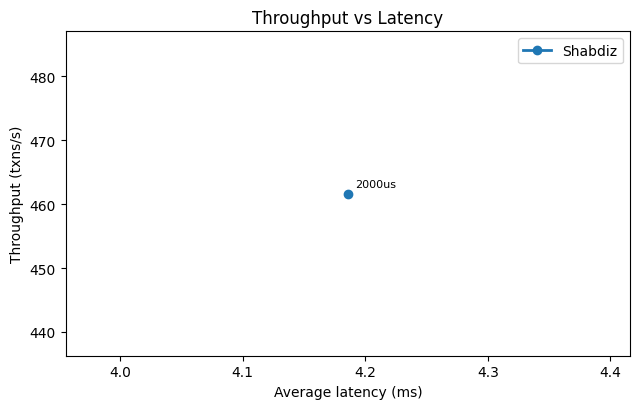

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np
from pathlib import Path

# ============================================================
# Leader logs, one per send_interval_us experiment.
# ============================================================
log_file_list = [
    "../work/experiments/shabdiz/shab_sleepbtw_request_8_0/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shab_sleepbtw_request_8_20/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shab_sleepbtw_request_8_50/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shab_sleepbtw_request_8_100/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shab_sleepbtw_request_8_500/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shab_sleepbtw_request_8_2000/tsm-sc-000/node1/stellar-core.log",
]

# Average window from the end of the experiment.
# If the run has fewer seconds than this, the script uses all available data.
AVG_WINDOW_START_FROM_END = 90
AVG_WINDOW_END_FROM_END = 30

# Choose x-axis latency metric for the final plot.
# Options: "mean", "median", "p95", "p99"
LATENCY_METRIC_FOR_PLOT = "mean"

OUTPUT_CSV = "throughput_latency_summary.csv"
OUTPUT_PNG = "throughput_vs_latency.png"
OUTPUT_PDF = "throughput_vs_latency.pdf"

TS = r"(?P<ts>\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3})"

# ============================================================
# Leader-side proposal patterns only.
# Latency start = leader proposal-send time.
# ============================================================
propose_patterns = [
    ("fast-send", re.compile(
        TS + r".*\[FAST SEND PROPOSE\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+).*txns=(?P<txns>\d+)"
    )),

    ("slow-send", re.compile(
        TS + r".*\[SLOW SEND PROPOSE\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+).*txns=(?P<txns>\d+)"
    )),

    # Optional older leader-side log.
    ("send-very-old", re.compile(
        TS + r".*prop\(\): .*proposing block (?P<block>\w+) in view (?P<view>\d+)"
    )),
]

# ============================================================
# Leader-side commit patterns.
# Throughput and latency end = leader commit time.
# ============================================================
commit_patterns = [
    ("shabdiz", re.compile(
        TS + r".*\[FAST COMMITTED\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+) txns=(?P<txns>\d+)"
    )),

    ("shabdiz-renamed", re.compile(
        TS + r".*\[SHABDIZ COMMITTED\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+) txns=(?P<txns>\d+)"
    )),

    ("iths", re.compile(
        TS + r".*\[IT-HS\] Committed block (?P<block>[0-9a-fA-F]+) view (?P<view>\d+) with (?P<txns>\d+) transactions"
    )),

    ("old", re.compile(
        TS + r".*Committed block (?P<block>\w+) at view (?P<view>\d+) with (?P<txns>\d+) transactions"
    )),
]

# Used only to label fast/slow path, not to filter throughput.
collect_patterns = [
    re.compile(TS + r".*Received COLLECT for view (?P<view>\d+)"),
    re.compile(TS + r".*Leader initiating COLLECT for view (?P<view>\d+)"),
]

def parse_ts(ts_str):
    return datetime.strptime(ts_str, "%Y-%m-%dT%H:%M:%S.%f")

def match_tagged(patterns, line):
    for tag, pat in patterns:
        m = pat.search(line)
        if m:
            return tag, m
    return None, None

def match_any(patterns, line):
    for pat in patterns:
        m = pat.search(line)
        if m:
            return m
    return None

def pick_window(values, start_from_end, end_from_end):
    values = np.asarray(values)

    if len(values) == 0:
        return values

    if len(values) >= start_from_end:
        return values[-start_from_end:-end_from_end]

    return values

def infer_send_interval_us(log_file):
    """
    Extracts send interval from paths like:
    shab_sleepbtw_request_8_100/...
    """
    m = re.search(r"sleepbtw_request_\d+_(\d+)", log_file)
    if m:
        return int(m.group(1))

    # Fallback: try the last number before /tsm-sc-
    m = re.search(r"_(\d+)/tsm-sc-", log_file)
    if m:
        return int(m.group(1))

    return None

def parse_one_leader_log(log_file):
    propose_times = {}
    propose_sources = {}

    commit_times = {}
    batch_sizes = {}
    commit_sources = {}

    collect_views = set()
    slow_proposal_views = set()

    with open(log_file, errors="ignore") as f:
        for line in f:
            collect_match = match_any(collect_patterns, line)
            if collect_match:
                view = int(collect_match.group("view"))
                collect_views.add(view)
                continue

            ptag, pmatch = match_tagged(propose_patterns, line)
            if pmatch:
                ts = parse_ts(pmatch.group("ts"))
                block = pmatch.group("block")
                view = int(pmatch.group("view"))
                key = (block, view)

                if ptag == "slow-send":
                    slow_proposal_views.add(view)

                if key not in propose_times or ts < propose_times[key]:
                    propose_times[key] = ts
                    propose_sources[key] = ptag

                continue

            ctag, cmatch = match_tagged(commit_patterns, line)
            if cmatch:
                ts = parse_ts(cmatch.group("ts"))
                block = cmatch.group("block")
                view = int(cmatch.group("view"))
                txns = int(cmatch.group("txns"))
                key = (block, view)

                if key not in commit_times or ts < commit_times[key]:
                    commit_times[key] = ts
                    batch_sizes[key] = txns
                    commit_sources[key] = ctag

                continue

    if not commit_times:
        return None, None, {
            "error": "No commits found",
            "proposals": len(propose_times),
            "commits": 0,
        }

    commit_rows = []
    latency_rows = []

    for key, ctime in sorted(commit_times.items(), key=lambda x: x[1]):
        block, view = key
        txns = batch_sizes.get(key, 1)

        path = "slow" if (view in collect_views or view in slow_proposal_views) else "fast"

        commit_rows.append({
            "block": block,
            "view": view,
            "commit_time": ctime,
            "txn_count": txns,
            "path": path,
            "commit_source": commit_sources.get(key, "unknown"),
        })

        if key not in propose_times:
            continue

        ptime = propose_times[key]
        latency = (ctime - ptime).total_seconds()

        if latency < 0:
            continue

        latency_rows.append({
            "block": block,
            "view": view,
            "propose_time": ptime,
            "commit_time": ctime,
            "latency_sec": latency,
            "latency_ms": latency * 1000.0,
            "txn_count": txns,
            "path": path,
            "proposal_source": propose_sources.get(key, "unknown"),
            "commit_source": commit_sources.get(key, "unknown"),
        })

    commit_df = pd.DataFrame(commit_rows)
    lat_df = pd.DataFrame(latency_rows)

    all_times = list(commit_df["commit_time"])
    if not lat_df.empty:
        all_times += list(lat_df["propose_time"])

    start_time = min(all_times)

    commit_df["time_sec"] = (commit_df["commit_time"] - start_time).dt.total_seconds()
    commit_df["time_sec_floor"] = np.floor(commit_df["time_sec"]).astype(int)

    throughput = commit_df.groupby("time_sec_floor")["txn_count"].sum()

    full_tput_index = np.arange(
        int(throughput.index.min()),
        int(throughput.index.max()) + 1
    )
    throughput = throughput.reindex(full_tput_index, fill_value=0)

    tput_window = pick_window(
        throughput.values,
        AVG_WINDOW_START_FROM_END,
        AVG_WINDOW_END_FROM_END,
    )

    avg_tput = np.mean(tput_window) if len(tput_window) > 0 else np.nan

    # Overall throughput over commit span.
    commit_duration = (
        commit_df["commit_time"].max() - commit_df["commit_time"].min()
    ).total_seconds()

    if commit_duration > 0:
        overall_tput = commit_df["txn_count"].sum() / commit_duration
    else:
        overall_tput = np.nan

    if not lat_df.empty:
        lat_df["time_sec"] = (lat_df["commit_time"] - start_time).dt.total_seconds()
        lat_df["time_sec_floor"] = np.floor(lat_df["time_sec"]).astype(int)

        latency_series_mean = lat_df.groupby("time_sec_floor")["latency_ms"].mean()
        latency_series_median = lat_df.groupby("time_sec_floor")["latency_ms"].median()

        full_lat_index = np.arange(
            int(latency_series_mean.index.min()),
            int(latency_series_mean.index.max()) + 1
        )

        latency_series_mean = latency_series_mean.reindex(full_lat_index, fill_value=np.nan)
        latency_series_median = latency_series_median.reindex(full_lat_index, fill_value=np.nan)

        mean_lat_window = pick_window(
            latency_series_mean.values,
            AVG_WINDOW_START_FROM_END,
            AVG_WINDOW_END_FROM_END,
        )

        median_lat_window = pick_window(
            latency_series_median.values,
            AVG_WINDOW_START_FROM_END,
            AVG_WINDOW_END_FROM_END,
        )

        stable_avg_latency_ms = np.nanmean(mean_lat_window)
        stable_median_latency_ms = np.nanmedian(median_lat_window)

        overall_avg_latency_ms = lat_df["latency_ms"].mean()
        overall_median_latency_ms = lat_df["latency_ms"].median()
        overall_p95_latency_ms = lat_df["latency_ms"].quantile(0.95)
        overall_p99_latency_ms = lat_df["latency_ms"].quantile(0.99)
    else:
        stable_avg_latency_ms = np.nan
        stable_median_latency_ms = np.nan
        overall_avg_latency_ms = np.nan
        overall_median_latency_ms = np.nan
        overall_p95_latency_ms = np.nan
        overall_p99_latency_ms = np.nan

    summary = {
        "log_file": log_file,
        "send_interval_us": infer_send_interval_us(log_file),
        "leader_proposals_matched": len(propose_times),
        "leader_commits_matched": len(commit_times),
        "latency_pairs_matched": len(lat_df),
        "total_committed_txns": int(commit_df["txn_count"].sum()),
        "committed_blocks": len(commit_df),
        "fast_blocks": int((commit_df["path"] == "fast").sum()),
        "slow_blocks": int((commit_df["path"] == "slow").sum()),
        "stable_avg_throughput_tps": avg_tput,
        "overall_throughput_tps": overall_tput,
        "stable_avg_latency_ms": stable_avg_latency_ms,
        "stable_median_latency_ms": stable_median_latency_ms,
        "overall_avg_latency_ms": overall_avg_latency_ms,
        "overall_median_latency_ms": overall_median_latency_ms,
        "overall_p95_latency_ms": overall_p95_latency_ms,
        "overall_p99_latency_ms": overall_p99_latency_ms,
        "commit_duration_sec": commit_duration,
    }

    return commit_df, lat_df, summary

# ============================================================
# Parse all logs.
# ============================================================
summaries = []

for log_file in log_file_list:
    print(f"Processing leader log: {log_file}")

    if not Path(log_file).exists():
        print(f"  WARNING: file not found: {log_file}")
        summaries.append({
            "log_file": log_file,
            "send_interval_us": infer_send_interval_us(log_file),
            "error": "file not found",
        })
        continue

    commit_df, lat_df, summary = parse_one_leader_log(log_file)

    if summary.get("error"):
        print(f"  WARNING: {summary['error']}")
    else:
        print(
            f"  interval={summary['send_interval_us']} us, "
            f"tput={summary['stable_avg_throughput_tps']:.2f} txns/s, "
            f"avg_lat={summary['stable_avg_latency_ms']:.2f} ms, "
            f"median_lat={summary['stable_median_latency_ms']:.2f} ms"
        )

    summaries.append(summary)

summary_df = pd.DataFrame(summaries)

# Keep only successful rows for plotting.
plot_df = summary_df.dropna(subset=[
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
]).copy()

plot_df = plot_df.sort_values("send_interval_us")

summary_df.to_csv(OUTPUT_CSV, index=False)

print("\nSummary:")
print(summary_df[[
    "send_interval_us",
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
    "stable_median_latency_ms",
    "overall_p95_latency_ms",
    "overall_p99_latency_ms",
    "total_committed_txns",
    "committed_blocks",
    "fast_blocks",
    "slow_blocks",
]])

print(f"\nSaved summary CSV to: {OUTPUT_CSV}")

if plot_df.empty:
    print("No valid points to plot.")
else:
    if LATENCY_METRIC_FOR_PLOT == "mean":
        latency_col = "stable_avg_latency_ms"
        latency_label = "Average latency (ms)"
    elif LATENCY_METRIC_FOR_PLOT == "median":
        latency_col = "stable_median_latency_ms"
        latency_label = "Median latency (ms)"
    elif LATENCY_METRIC_FOR_PLOT == "p95":
        latency_col = "overall_p95_latency_ms"
        latency_label = "P95 latency (ms)"
    elif LATENCY_METRIC_FOR_PLOT == "p99":
        latency_col = "overall_p99_latency_ms"
        latency_label = "P99 latency (ms)"
    else:
        raise ValueError(f"Unknown LATENCY_METRIC_FOR_PLOT={LATENCY_METRIC_FOR_PLOT}")

    plt.figure(figsize=(6.5, 4.2))

    # Throughput-vs-latency curve.
    plt.plot(
        plot_df[latency_col],
        plot_df["stable_avg_throughput_tps"],
        marker="o",
        linewidth=2,
        label="Shabdiz"
    )

    # Annotate each point with send interval.
    for _, row in plot_df.iterrows():
        plt.annotate(
            f"{int(row['send_interval_us'])}us",
            (row[latency_col], row["stable_avg_throughput_tps"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

    plt.xlabel(latency_label)
    plt.ylabel("Throughput (txns/s)")
    plt.title("Throughput vs Latency")
    # plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
    # plt.savefig(OUTPUT_PDF, bbox_inches="tight")

    print(f"Saved plot to: {OUTPUT_PNG}")
    print(f"Saved plot to: {OUTPUT_PDF}")

    plt.show()

Processing IT-HotStuff leader log: ../work/experiments/shabdiz/ITHS_tplat_4/tsm-sc-000/node1/stellar-core.log
  nodes=4, stable_tput=23470.00 txns/s, stable_avg_latency=3.61 ms, stable_median_latency=3.00 ms
Processing IT-HotStuff leader log: ../work/experiments/shabdiz/ITHS_tplat_8/tsm-sc-000/node1/stellar-core.log
  nodes=8, stable_tput=18410.00 txns/s, stable_avg_latency=4.72 ms, stable_median_latency=4.00 ms
Processing IT-HotStuff leader log: ../work/experiments/shabdiz/ITHS_tplat_16/tsm-sc-000/node1/stellar-core.log
  nodes=16, stable_tput=9410.00 txns/s, stable_avg_latency=9.98 ms, stable_median_latency=9.00 ms
Processing IT-HotStuff leader log: ../work/experiments/shabdiz/ITHS_tplat_32/tsm-sc-000/node1/stellar-core.log
  nodes=32, stable_tput=3893.33 txns/s, stable_avg_latency=25.82 ms, stable_median_latency=21.50 ms
Processing IT-HotStuff leader log: ../work/experiments/shabdiz/ITHS_tplat_48/tsm-sc-000/node1/stellar-core.log
  nodes=48, stable_tput=1576.67 txns/s, stable_avg_la

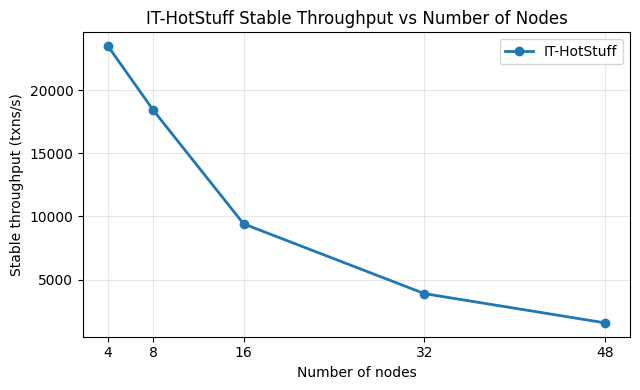

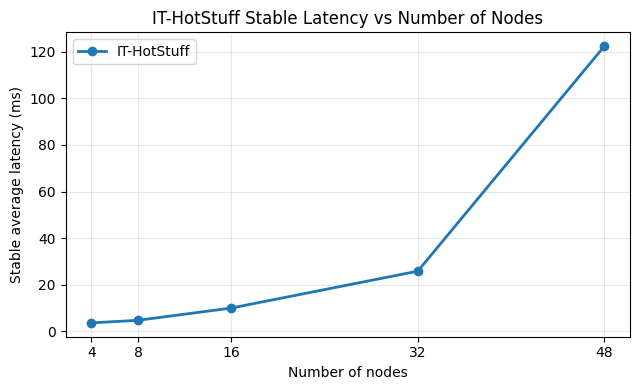

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np
from pathlib import Path

# IT-HotStuff leader logs, one per node-count experiment.
log_file_list = [
    "../work/experiments/shabdiz/ITHS_tplat_4/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/ITHS_tplat_8/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/ITHS_tplat_16/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/ITHS_tplat_32/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/ITHS_tplat_48/tsm-sc-000/node1/stellar-core.log",
]

AVG_WINDOW_START_FROM_END = 60
AVG_WINDOW_END_FROM_END = 30

TS = r"(?P<ts>\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3})"

# Leader-side proposal-send logs only.
# Do not include "[IT-HS] Received PROPOSE" if this is leader-only latency.
propose_patterns = [
    re.compile(
        TS + r".*\[FAST SEND PROPOSE\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+)"
    ),
    re.compile(
        TS + r".*prop\(\): .*proposing block (?P<block>\w+) in view (?P<view>\d+)"
    ),
]

# IT-HotStuff commit logs.
commit_patterns = [
    re.compile(
        TS + r".*\[IT-HS\] Committed block (?P<block>[0-9a-fA-F]+) view (?P<view>\d+) with (?P<txns>\d+) transactions"
    ),
]

def parse_ts(ts_str):
    return datetime.strptime(ts_str, "%Y-%m-%dT%H:%M:%S.%f")

def match_any(patterns, line):
    for pat in patterns:
        m = pat.search(line)
        if m:
            return m
    return None

def pick_window(values, start_from_end, end_from_end):
    values = np.asarray(values)

    if len(values) == 0:
        return values

    if len(values) >= start_from_end:
        return values[-start_from_end:-end_from_end]

    return values

def infer_num_nodes(log_file):
    """
    Extracts node count from paths like:
    iths_tplat_48/...
    shabdiz_tplat_48/...
    """
    m = re.search(r"tplat_(\d+)", log_file)
    if m:
        return int(m.group(1))

    m = re.search(r"_(\d+)/tsm-sc-", log_file)
    if m:
        return int(m.group(1))

    return None

def parse_one_iths_leader_log(log_file):
    propose_times = {}
    commit_times = {}
    batch_sizes = {}

    with open(log_file, errors="ignore") as f:
        for line in f:
            pmatch = match_any(propose_patterns, line)
            if pmatch:
                ts = parse_ts(pmatch.group("ts"))
                block = pmatch.group("block")
                view = int(pmatch.group("view"))
                key = (block, view)

                if key not in propose_times or ts < propose_times[key]:
                    propose_times[key] = ts

                continue

            cmatch = match_any(commit_patterns, line)
            if cmatch:
                ts = parse_ts(cmatch.group("ts"))
                block = cmatch.group("block")
                view = int(cmatch.group("view"))
                txns = int(cmatch.group("txns"))
                key = (block, view)

                if key not in commit_times or ts < commit_times[key]:
                    commit_times[key] = ts
                    batch_sizes[key] = txns

                continue

    if not commit_times:
        return {
            "num_nodes": infer_num_nodes(log_file),
            "log_file": log_file,
            "error": "No commits found",
            "proposals_matched": len(propose_times),
            "commits_matched": 0,
        }

    commit_rows = []
    latency_rows = []

    for key, ctime in sorted(commit_times.items(), key=lambda x: x[1]):
        block, view = key
        txns = batch_sizes.get(key, 100)

        # Throughput should count all committed blocks.
        commit_rows.append({
            "block": block,
            "view": view,
            "commit_time": ctime,
            "txn_count": txns,
        })

        # Latency requires matching leader-side proposal-send.
        if key not in propose_times:
            continue

        ptime = propose_times[key]
        latency_sec = (ctime - ptime).total_seconds()

        if latency_sec < 0:
            continue

        latency_rows.append({
            "block": block,
            "view": view,
            "propose_time": ptime,
            "commit_time": ctime,
            "latency_sec": latency_sec,
            "latency_ms": latency_sec * 1000.0,
            "txn_count": txns,
        })

    commit_df = pd.DataFrame(commit_rows)
    lat_df = pd.DataFrame(latency_rows)

    all_times = list(commit_df["commit_time"])
    if not lat_df.empty:
        all_times += list(lat_df["propose_time"])

    start_time = min(all_times)

    commit_df["time_sec"] = (commit_df["commit_time"] - start_time).dt.total_seconds()
    commit_df["time_sec_floor"] = np.floor(commit_df["time_sec"]).astype(int)

    # Stable throughput.
    throughput_series = commit_df.groupby("time_sec_floor")["txn_count"].sum()

    full_tput_index = np.arange(
        int(throughput_series.index.min()),
        int(throughput_series.index.max()) + 1
    )
    throughput_series = throughput_series.reindex(full_tput_index, fill_value=0)

    tput_window = pick_window(
        throughput_series.values,
        AVG_WINDOW_START_FROM_END,
        AVG_WINDOW_END_FROM_END,
    )

    stable_avg_tput = np.mean(tput_window) if len(tput_window) > 0 else np.nan

    # Stable latency.
    if not lat_df.empty:
        lat_df["time_sec"] = (lat_df["commit_time"] - start_time).dt.total_seconds()
        lat_df["time_sec_floor"] = np.floor(lat_df["time_sec"]).astype(int)

        latency_series_mean = lat_df.groupby("time_sec_floor")["latency_ms"].mean()
        latency_series_median = lat_df.groupby("time_sec_floor")["latency_ms"].median()

        full_lat_index = np.arange(
            int(latency_series_mean.index.min()),
            int(latency_series_mean.index.max()) + 1
        )

        latency_series_mean = latency_series_mean.reindex(full_lat_index, fill_value=np.nan)
        latency_series_median = latency_series_median.reindex(full_lat_index, fill_value=np.nan)

        mean_lat_window = pick_window(
            latency_series_mean.values,
            AVG_WINDOW_START_FROM_END,
            AVG_WINDOW_END_FROM_END,
        )

        median_lat_window = pick_window(
            latency_series_median.values,
            AVG_WINDOW_START_FROM_END,
            AVG_WINDOW_END_FROM_END,
        )

        stable_avg_latency_ms = np.nanmean(mean_lat_window)
        stable_median_latency_ms = np.nanmedian(median_lat_window)

        overall_avg_latency_ms = lat_df["latency_ms"].mean()
        overall_median_latency_ms = lat_df["latency_ms"].median()
        overall_p95_latency_ms = lat_df["latency_ms"].quantile(0.95)
        overall_p99_latency_ms = lat_df["latency_ms"].quantile(0.99)
    else:
        stable_avg_latency_ms = np.nan
        stable_median_latency_ms = np.nan
        overall_avg_latency_ms = np.nan
        overall_median_latency_ms = np.nan
        overall_p95_latency_ms = np.nan
        overall_p99_latency_ms = np.nan

    commit_duration_sec = (
        commit_df["commit_time"].max() - commit_df["commit_time"].min()
    ).total_seconds()

    if commit_duration_sec > 0:
        overall_tput = commit_df["txn_count"].sum() / commit_duration_sec
    else:
        overall_tput = np.nan

    return {
        "num_nodes": infer_num_nodes(log_file),
        "log_file": log_file,
        "proposals_matched": len(propose_times),
        "commits_matched": len(commit_times),
        "latency_pairs_matched": len(lat_df),
        "total_committed_txns": int(commit_df["txn_count"].sum()),
        "committed_blocks": len(commit_df),
        "stable_avg_throughput_tps": stable_avg_tput,
        "overall_throughput_tps": overall_tput,
        "stable_avg_latency_ms": stable_avg_latency_ms,
        "stable_median_latency_ms": stable_median_latency_ms,
        "overall_avg_latency_ms": overall_avg_latency_ms,
        "overall_median_latency_ms": overall_median_latency_ms,
        "overall_p95_latency_ms": overall_p95_latency_ms,
        "overall_p99_latency_ms": overall_p99_latency_ms,
        "commit_duration_sec": commit_duration_sec,
        "error": None,
    }

# ============================================================
# Parse all logs.
# ============================================================
summaries = []

for log_file in log_file_list:
    print(f"Processing IT-HotStuff leader log: {log_file}")

    if not Path(log_file).exists():
        print(f"  WARNING: file not found: {log_file}")
        summaries.append({
            "num_nodes": infer_num_nodes(log_file),
            "log_file": log_file,
            "error": "file not found",
        })
        continue

    summary = parse_one_iths_leader_log(log_file)

    if summary.get("error"):
        print(f"  WARNING: {summary['error']}")
    else:
        print(
            f"  nodes={summary['num_nodes']}, "
            f"stable_tput={summary['stable_avg_throughput_tps']:.2f} txns/s, "
            f"stable_avg_latency={summary['stable_avg_latency_ms']:.2f} ms, "
            f"stable_median_latency={summary['stable_median_latency_ms']:.2f} ms"
        )

    summaries.append(summary)

summary_df = pd.DataFrame(summaries)

plot_df = summary_df.dropna(subset=[
    "num_nodes",
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
]).copy()

plot_df = plot_df.sort_values("num_nodes")

print("\nSummary:")
print(summary_df[[
    "num_nodes",
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
    "stable_median_latency_ms",
    "overall_p95_latency_ms",
    "overall_p99_latency_ms",
    "total_committed_txns",
    "committed_blocks",
    "latency_pairs_matched",
    "error",
]])

if plot_df.empty:
    print("No valid IT-HotStuff results to plot.")
else:
    # ============================================================
    # Final plot 1: stable throughput vs number of nodes.
    # ============================================================
    plt.figure(figsize=(6.5, 4.0))
    plt.plot(
        plot_df["num_nodes"],
        plot_df["stable_avg_throughput_tps"],
        marker="o",
        linewidth=2,
        label="IT-HotStuff",
    )
    plt.xlabel("Number of nodes")
    plt.ylabel("Stable throughput (txns/s)")
    plt.title("IT-HotStuff Stable Throughput vs Number of Nodes")
    plt.xticks(plot_df["num_nodes"].astype(int).tolist())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ============================================================
    # Final plot 2: stable latency vs number of nodes.
    # ============================================================
    plt.figure(figsize=(6.5, 4.0))
    plt.plot(
        plot_df["num_nodes"],
        plot_df["stable_avg_latency_ms"],
        marker="o",
        linewidth=2,
        label="IT-HotStuff",
    )
    plt.xlabel("Number of nodes")
    plt.ylabel("Stable average latency (ms)")
    plt.title("IT-HotStuff Stable Latency vs Number of Nodes")
    plt.xticks(plot_df["num_nodes"].astype(int).tolist())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [2]:
18226 *100 / 18

101255.55555555556

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/test_4_refine/tsm-sc-001/node2/stellar-core.log'
                ]


throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # ---- Plot Throughput ----
    plt.figure(figsize=(10, 4))
    plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.ylim(0, throughput.values.max() * 1.2)
    plt.title("Throughput vs Time (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # ---- Plot Latency ----
    plt.figure(figsize=(10, 4))
    plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

# Comparison with Stellar

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/nr_4/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_8/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_16/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/nr_32/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_48/tsm-sc-001/node2/stellar-core.log']


throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # # ---- Plot Throughput ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    # plt.xlabel("Time (s)")
    # plt.ylabel("Transactions/sec")
    # plt.ylim(0, throughput.values.max() * 1.2)
    # plt.title("Throughput vs Time (Normal Consensus Only)")
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("throughput.png", dpi=150)
    # plt.show()
    
    # # ---- Plot Latency ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    # plt.xlabel("Time (s)")
    # plt.ylabel("Latency (s)")
    # plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("latency.png", dpi=150)
    # plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

# Collection vs Node Count

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = [
                '../work/experiments/stellar-core/collection_300_rounds_4_v2/tsm-sc-000/node1/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_300_rounds_8_v2/tsm-sc-000/node1/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_300_rounds_16_v2/tsm-sc-000/node1/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_300_rounds_32_v2/tsm-sc-000/node1/stellar-core.log']


# -----------------------------
# Regex patterns
# -----------------------------
prop_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"prop\(\): Leader proposing block (\w+) in view (\d+)"
)

collect_start_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Leader initiating COLLECT for view (\d+)"
)

commit_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Committed block (\w+) at view (\d+) with (\d+) transactions"
)

throughput_list = []
latency_list = []

# -----------------------------
# Process logs
# -----------------------------
for log_file in log_file_list:
    print(f"\nProcessing: {log_file}")

    start_times = {}   # view -> earliest start
    commit_times = {}  # view -> commit time
    batch_sizes = {}   # view -> txn count

    with open(log_file) as f:
        for line in f:
            # ---- Normal proposal start ----
            m = prop_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- COLLECT start ----
            m = collect_start_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(2))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- Commit ----
            m = commit_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                batch = int(m.group(4))
                commit_times[view] = ts
                batch_sizes[view] = batch

    # -----------------------------
    # Build metrics
    # -----------------------------
    rows = []
    for view, ctime in commit_times.items():
        if view not in start_times:
            continue

        latency = (ctime - start_times[view]).total_seconds()
        rows.append({
            "view": view,
            "commit_time": ctime,
            "latency": latency,
            "txns": batch_sizes[view],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No valid data found.")
        continue

    # -----------------------------
    # Normalize time
    # -----------------------------
    t0 = min(start_times.values())
    df["time_sec"] = df["commit_time"].apply(
        lambda t: (t - t0).total_seconds()
    )
    df["time_round"] = df["time_sec"].round().astype(int)

    # -----------------------------
    # Throughput
    # -----------------------------
    throughput = df.groupby("time_round")["txns"].sum()
    throughput = throughput.reindex(
        np.arange(throughput.index.min(), throughput.index.max() + 1),
        fill_value=0
    )

    # -----------------------------
    # Latency
    # -----------------------------
    latency_series = df.groupby("time_round")["latency"].mean()
    latency_series = latency_series.reindex(
        np.arange(latency_series.index.min(), latency_series.index.max() + 1),
        fill_value=0
    )


    throughput_list.append(throughput)
    latency_list.append(latency_series)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(throughput.index, throughput.values)
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.title("Throughput vs Time")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(latency_series.index, latency_series.values, color="red")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Start → Commit Latency")
    plt.tight_layout()
    plt.show()

    print("Average Throughput:", np.mean(throughput.values[-90:-30]))
    print("Average Latency:", np.mean(latency_series.values[-90:-30]))

In [ ]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.10,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



node_list = [4, 8, 16, 32]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    val = np.nanmean(throughput_ma.values[40:95])
    plt.plot(
        throughput_ma.index[30:150],
        throughput_ma.values[30:150]/val,
        "-",
        label=f"{node_list[i]} nodes, f={val:.1e}"
    )




plt.ylim(0,1.5)
    

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — SHABDIZ")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/collect_vs_nodes_thput.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()

    val = np.nanmean(latency_ma.values[40:95])

    plt.plot(
        latency_ma.index[30:150],
        latency_ma.values[30:150]/val,
        "-",
        label=f"{node_list[i]} nodes, f={val:.1e}"
    )

plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — SHABDIZ")
# plt.title("Proposal to Commit Latency (During Collection)")
# plt.ylim(0.5,1.5)

plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)

plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/collect_vs_nodes_lat.pdf", dpi=150)
plt.show()


# Collection Vs Collect Rounds

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/collection_5_rounds_16_v2/tsm-sc-000/node1/stellar-core.log',\
                '../work/experiments/stellar-core/collection_50_rounds_16_v2/tsm-sc-000/node1/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_300_rounds_16_v2/tsm-sc-000/node1/stellar-core.log',\
                '../work/experiments/stellar-core/collection_500_rounds_16_v2/tsm-sc-000/node1/stellar-core.log']



# -----------------------------
# Regex patterns
# -----------------------------
prop_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"prop\(\): Leader proposing block (\w+) in view (\d+)"
)

collect_start_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Leader initiating COLLECT for view (\d+)"
)

commit_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Committed block (\w+) at view (\d+) with (\d+) transactions"
)

throughput_list = []
latency_list = []

# -----------------------------
# Process logs
# -----------------------------
for log_file in log_file_list:
    print(f"\nProcessing: {log_file}")

    start_times = {}   # view -> earliest start
    commit_times = {}  # view -> commit time
    batch_sizes = {}   # view -> txn count

    with open(log_file) as f:
        for line in f:
            # ---- Normal proposal start ----
            m = prop_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- COLLECT start ----
            m = collect_start_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(2))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- Commit ----
            m = commit_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                batch = int(m.group(4))
                commit_times[view] = ts
                batch_sizes[view] = batch

    # -----------------------------
    # Build metrics
    # -----------------------------
    rows = []
    for view, ctime in commit_times.items():
        if view not in start_times:
            continue

        latency = (ctime - start_times[view]).total_seconds()
        rows.append({
            "view": view,
            "commit_time": ctime,
            "latency": latency,
            "txns": batch_sizes[view],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No valid data found.")
        continue

    # -----------------------------
    # Normalize time
    # -----------------------------
    t0 = min(start_times.values())
    df["time_sec"] = df["commit_time"].apply(
        lambda t: (t - t0).total_seconds()
    )
    df["time_round"] = df["time_sec"].round().astype(int)

    # -----------------------------
    # Throughput
    # -----------------------------
    throughput = df.groupby("time_round")["txns"].sum()
    throughput = throughput.reindex(
        np.arange(throughput.index.min(), throughput.index.max() + 1),
        fill_value=0
    )

    # -----------------------------
    # Latency
    # -----------------------------
    latency_series = df.groupby("time_round")["latency"].mean()
    latency_series = latency_series.reindex(
        np.arange(latency_series.index.min(), latency_series.index.max() + 1),
        fill_value=0
    )


    throughput_list.append(throughput)
    latency_list.append(latency_series)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(throughput.index, throughput.values)
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.title("Throughput vs Time")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(latency_series.index, latency_series.values, color="red")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Start → Commit Latency")
    plt.tight_layout()
    plt.show()

    print("Average Throughput:", np.mean(throughput.values[-90:-30]))
    print("Average Latency:", np.mean(latency_series.values[-90:-30]))

In [ ]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.08,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



round_list = [5, 50,300, 500]
window = 2  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    plt.plot(
        throughput_ma.index[40:150],
        throughput_ma.values[40:150],
        "-",
        label=f"{round_list[i]} cr"
    )

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — SHABDIZ")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/thput_vs_collect_rounds.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index[40:150],
        latency_ma.values[40:150],
        "-",
        label=f"{round_list[i]} cr"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — SHABDIZ")
# plt.title("Proposal to Commit Latency (During Collection)")


plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)

plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/lat_vs_collect_rounds.pdf", dpi=150)
plt.show()


# Collection Vs Network Latency


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# -----------------------------
# Log files
# -----------------------------
log_file_list = [
    '../work/experiments/stellar-core/collection_10_rounds_16_zone_0_v2/tsm-sc-000/node1/stellar-core.log',
    '../work/experiments/stellar-core/collection_10_rounds_16_zone_1_v2/tsm-sc-000/node1/stellar-core.log',
    '../work/experiments/stellar-core/collection_10_rounds_16_zone_2_v2/tsm-sc-000/node1/stellar-core.log',
    '../work/experiments/stellar-core/collection_10_rounds_16_zone_3_v2/tsm-sc-000/node1/stellar-core.log',
    '../work/experiments/stellar-core/collection_10_rounds_16_zone_4_v2/tsm-sc-000/node1/stellar-core.log',
]

# -----------------------------
# Regex patterns
# -----------------------------
prop_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"prop\(\): Leader proposing block (\w+) in view (\d+)"
)

collect_start_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Leader initiating COLLECT for view (\d+)"
)

commit_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Committed block (\w+) at view (\d+) with (\d+) transactions"
)

throughput_list = []
latency_list = []

# -----------------------------
# Process logs
# -----------------------------
for log_file in log_file_list:
    print(f"\nProcessing: {log_file}")

    start_times = {}   # view -> earliest start
    commit_times = {}  # view -> commit time
    batch_sizes = {}   # view -> txn count

    with open(log_file) as f:
        for line in f:
            # ---- Normal proposal start ----
            m = prop_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- COLLECT start ----
            m = collect_start_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(2))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- Commit ----
            m = commit_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                batch = int(m.group(4))
                commit_times[view] = ts
                batch_sizes[view] = batch

    # -----------------------------
    # Build metrics
    # -----------------------------
    rows = []
    for view, ctime in commit_times.items():
        if view not in start_times:
            continue

        latency = (ctime - start_times[view]).total_seconds()
        rows.append({
            "view": view,
            "commit_time": ctime,
            "latency": latency,
            "txns": batch_sizes[view],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No valid data found.")
        continue

    # -----------------------------
    # Normalize time
    # -----------------------------
    t0 = min(start_times.values())
    df["time_sec"] = df["commit_time"].apply(
        lambda t: (t - t0).total_seconds()
    )
    df["time_round"] = df["time_sec"].round().astype(int)

    # -----------------------------
    # Throughput
    # -----------------------------
    throughput = df.groupby("time_round")["txns"].sum()
    throughput = throughput.reindex(
        np.arange(throughput.index.min(), throughput.index.max() + 1),
        fill_value=0
    )

    # -----------------------------
    # Latency
    # -----------------------------
    latency_series = df.groupby("time_round")["latency"].mean()
    latency_series = latency_series.reindex(
        np.arange(latency_series.index.min(), latency_series.index.max() + 1),
        fill_value=0
    )


    throughput_list.append(throughput)
    latency_list.append(latency_series)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(throughput.index, throughput.values)
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.title("Throughput vs Time")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(latency_series.index, latency_series.values, color="red")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Start → Commit Latency")
    plt.tight_layout()
    plt.show()

    print("Average Throughput:", np.mean(throughput.values[-90:-30]))
    print("Average Latency:", np.mean(latency_series.values[-90:-30]))


In [ ]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.08,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



nl_list = [0,52, 91, 148, 214]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    print(np.nanmean(np.array(throughput_ma.values[:150])))
    val = np.nanmean(throughput_ma.values[40:95])

    
    plt.plot(
        throughput_ma.index[30:150],
        throughput_ma.values[30:150]/val,
        "-",
        label=f"NL={nl_list[i]}, f={val:.1e}"
    )


plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — SHABDIZ")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(x=99, color = 'black', linewidth=1.5, linestyle="--",alpha=0.8, label = 'Collection Start')


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/thput_vs_NL.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    val = np.nanmean(latency_ma.values[40:95])

    plt.plot(
        latency_ma.index[30:150],
        latency_ma.values[30:150]/ np.nanmean(np.array(latency_ma.values[40:95])),
        "-",
        label=f"NL={nl_list[i]}, f={val:.1e}"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — SHABDIZ")
# plt.title("Proposal to Commit Latency (During Collection)")


plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start')


# plt.ylim(0.6,1.5)
plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/lat_vs_NL.pdf", dpi=150)
plt.show()


# Memory Plots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# log_file_list = [
#     '../work/experiments/stellar-core/memory_4_no_cleanup/tsm-sc-001/node2/stellar-core.log',
#     '../work/experiments/stellar-core/memory_4_regular_cleanup/tsm-sc-001/node2/stellar-core.log',
#     '../work/experiments/stellar-core/memory_4_test/tsm-sc-001/node2/stellar-core.log'
# ]

log_file_list = [
    '../work/experiments/stellar-core/memory_4_no_cleanup_v2/tsm-sc-001/node2/stellar-core.log',
    '../work/experiments/stellar-core/memory_4_regular_cleanup_v2/tsm-sc-001/node2/stellar-core.log',
    '../work/experiments/stellar-core/memory_4_node_failure_v2/tsm-sc-001/node2/stellar-core.log'
]


memory_series_list = []
elements_series_list = []

# Updated regex: RSS + element count
memory_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*MEMORY RSS:\s+(\d+)\s+MB,\s+number of elements:\s+(\d+)"
)

for log_file in log_file_list:
    print(f"Processing: {log_file}")

    timestamps = []
    memory_mb = []
    elements = []

    with open(log_file) as f:
        for line in f:
            match = memory_pattern.search(line)
            if match:
                ts = datetime.strptime(match.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                mem = int(match.group(2))
                elems = int(match.group(3))

                timestamps.append(ts)
                memory_mb.append(mem)
                elements.append(elems)

    if not timestamps:
        print("⚠️ No memory entries found")
        continue

    # Normalize time
    start_time = min(timestamps)
    time_sec = [(t - start_time).total_seconds() for t in timestamps]

    df = pd.DataFrame({
        "time_sec": time_sec,
        "memory_mb": memory_mb,
        "elements": elements
    }).set_index("time_sec")

    # Aggregate per second
    df = df.groupby(df.index.round()).mean()

    # Fill missing seconds
    full_index = np.arange(
        int(np.floor(df.index.min())),
        int(np.ceil(df.index.max())) + 1
    )
    df = df.reindex(full_index).interpolate()

    memory_series_list.append(df["memory_mb"])
    elements_series_list.append(df["elements"])

    print("Average RSS (MB):", np.mean(df["memory_mb"].values[-90:-30]))


In [ ]:
    


import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt
    base = 0.05 * height_pt

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.10,
    }


# -----------------------------
# Global style
# -----------------------------
fig_w, fig_h = 12, 8  # inches
mpl.rcParams.update(font_scale_from_figsize(fig_w, fig_h))

label_list = ['(1) never pruned', '(2.1) SHABDIZ, no failures', '(2.2) SHABDIZ, failures']
# label_list = ['cleanup',  'regular failure injection']

window = 1  # moving average window

# -----------------------------
# Plot Memory
# -----------------------------
plt.figure(figsize=(12, 8))
ax = plt.gca()
ax_r = ax.twinx()

for i, mem_series in enumerate(memory_series_list):
    mem_ma = mem_series.rolling(window=window, center=True).mean()

    if i == 0:
        ax_r.plot(
            mem_ma.index[:150],
            mem_ma.values[:150],
            label=label_list[i],
            linestyle="--", color ='red'
        )
    else:
        ax.plot(
            mem_ma.index[:150],
            mem_ma.values[:150],
            "-",
            label=label_list[i]
        )

ax.set_ylim(30,200)

ax.set_xlabel("Time (s)")


ax.set_ylabel(r"Memory Usage (MB)$_{(2.1,\,2.2)}$")
ax_r.set_ylabel(r"Memory Usage (MB)$_{(1)}$")

# Combine legends
lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, frameon=False)

# Formatting
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))
ax.yaxis.set_major_formatter(formatter)
ax_r.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/memory.pdf", dpi=150)
plt.show()


from matplotlib.ticker import ScalarFormatter

class SciFormatter(ScalarFormatter):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.set_powerlimits((0, 0))  # always scientific

    def _set_format(self):
        self.format = "%.2f"


plt.figure(figsize=(12, 8))
ax = plt.gca()
ax_r = ax.twinx()

for i, elem_series in enumerate(elements_series_list):
    elem_ma = elem_series.rolling(window=window, center=True).mean()

    if i == 0:
        ax_r.plot(
            elem_ma.index[:150],
            elem_ma.values[:150],
            label=label_list[i],
            linestyle="--", color ='red'
        )
    else:
        ax.plot(
            elem_ma.index[:150],
            elem_ma.values[:150],
            label=label_list[i],
            linestyle="-"
        )

ax.set_ylim(0,9000)



ax.set_xlabel("Time (s)")



ax.set_ylabel(r"element count $_{(2.1,\,2.2)}$")
ax_r.set_ylabel(r"element count $_{(1)}$")


# --- scientific notation, 2 digits, exponent on top ---
fmt = SciFormatter(useMathText=True)
ax.yaxis.set_major_formatter(fmt)
ax_r.yaxis.set_major_formatter(fmt)

# Move ×10^n to top
ax.yaxis.get_offset_text().set_position((0, 1.02))
ax_r.yaxis.get_offset_text().set_position((1, 1.02))

# Legend
lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, frameon=False, loc = 'upper left')

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/memory_elements.pdf", dpi=150)
plt.show()



## Failure Plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/memory_16_node_failure/tsm-sc-008/node9/stellar-core.log']


throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)



    
    
    
    import pylab as pl
    import matplotlib as mpl
    from matplotlib.ticker import ScalarFormatter
    import numpy as np
    from matplotlib.ticker import FuncFormatter
    
    
    def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
        """
        Returns a dict of font sizes scaled to figure size.
        """
        height_pt = fig_height_in * 72  # 1 inch = 72 pt
        base = 0.05 * height_pt
    
        return {
            "font.size": base,
            "axes.labelsize": base * 1.0,
            "xtick.labelsize": base * 0.85,
            "ytick.labelsize": base * 0.85,
            "legend.fontsize": base * 0.85,
            "axes.titlesize": base * 1.05,
            "lines.markersize": base * 0.55,
            "lines.linewidth": base * 0.10,
        }
    
    
    # # -----------------------------
    # # Global style
    # # -----------------------------
    # fig_w, fig_h = 12, 8  # inches
    # mpl.rcParams.update(font_scale_from_figsize(fig_w, fig_h))







    
    
    # # ---- Plot Throughput ----
    # plt.figure(figsize=(12, 8))
    # plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    # plt.xlabel("Time (s)")
    # plt.ylabel("Transactions/sec")
    # plt.ylim(0, throughput.values.max() * 1.2)
    # plt.axvline(x=140, label = 'Failure 1', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=150, label = 'Failure 2', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=160, label = 'Failure 3', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=170, label = 'Failure 4', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=180, label = 'Failure 5', color = 'black',linewidth=1.5,
    # linestyle="--")
    
    # plt.legend(frameon=False)
    # plt.tight_layout()
    # plt.savefig("../work/Stellar2/Figures/failure_thput.pdf", dpi=150)

    # plt.show()
    
    # # ---- Plot Latency ----
    # plt.figure(figsize=(12, 8))
    # plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    # plt.xlabel("Time (s)")
    # plt.ylabel("Latency (s)")

    # plt.axvline(x=140, label = 'Failure 1', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=150, label = 'Failure 2', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=160, label = 'Failure 3', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=170, label = 'Failure 4', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=180, label = 'Failure 5', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.legend(frameon=False)
    # plt.tight_layout()
    # plt.savefig("../work/Stellar2/Figures/failure_lat.pdf", dpi=150)

    # plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

In [ ]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.12,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



window = 5  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    plt.plot(
        throughput_ma.index[40:-5],
        throughput_ma.values[40:-5],
        "-"
    )

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s)")
# plt.title("Throughput vs Time (During Collection)")

for i in range(5):
    
    plt.axvline(
        x=140 + i * 10, color = 'black',linewidth=1.5,
        linestyle="--",
        alpha=0.8, label = 'Failure ' + str(i+1)
    )


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/failure_thput.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index[40:-5],
        latency_ma.values[40:-5],
        "-"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s)")
# plt.title("Proposal to Commit Latency (During Collection)")

for i in range(5):
    
    plt.axvline(
        x=140 + i * 10, color = 'black',linewidth=1.5,
        linestyle="--",
        alpha=0.8, label = 'Failure ' + str(i+1)
    )
plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/failure_lat.pdf", dpi=150)
plt.show()


In [ ]:
# # import os
# os.system('git add .; git commit -m "check"; git push')
